In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.lstm_model import (
    create_sequences,
    build_lstm,
    scale_data,
)

plt.style.use("ggplot")

I0000 00:00:1783157208.406214   78396 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783157208.512440   78396 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783157211.107836   78396 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
df = pd.read_csv(
    "../data/raw/TSLA.csv",
    parse_dates=["Date"]
)

df = df.set_index("Date")

df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [3]:
close = df["Close"].values

scaled, scaler = scale_data(close)

window = 60

X, y = create_sequences(
    scaled,
    window=window
)

print("Total sequences:", len(X))

Total sequences: 2831


In [4]:
model = build_lstm(window)

history = model.fit(
    X,
    y,
    epochs=10,
    batch_size=32,
    verbose=1
)

E0000 00:00:1783157229.390883   78396 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/welela/venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - loss: 0.0075
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - loss: 0.0013
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0011
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 9.0698e-04
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 8.1986e-04
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 8.6266e-04
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 6.9472e-04
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 6.8138e-04
Epoch 9/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 6.3503e-04
Epoch 10/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 5.6486e-04


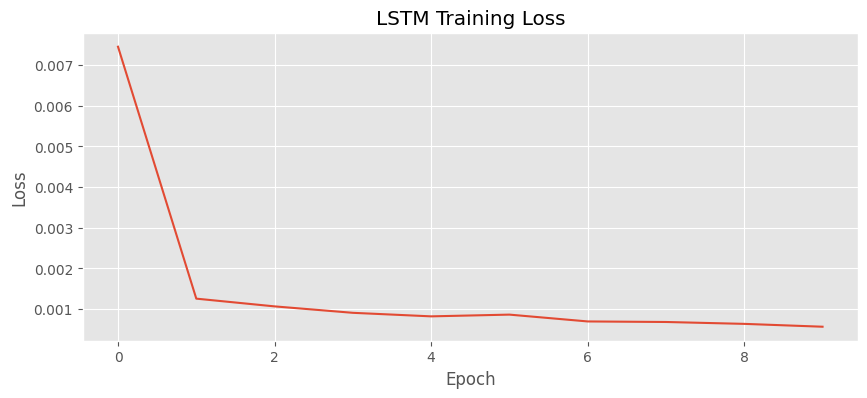

In [5]:
plt.figure(figsize=(10,4))

plt.plot(history.history["loss"])

plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [6]:
pred = model.predict(X)

pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(
    y.reshape(-1,1)
)

89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


In [7]:
future_steps = 180

last_sequence = scaled[-window:].copy()

future_predictions = []

current = last_sequence.copy()

for _ in range(future_steps):

    next_pred = model.predict(
        current.reshape(1, window, 1),
        verbose=0
    )

    future_predictions.append(next_pred[0,0])

    current = np.append(
        current[1:],
        next_pred
    )

future_predictions = np.array(
    future_predictions
).reshape(-1,1)

future_predictions = scaler.inverse_transform(
    future_predictions
)

In [8]:
residual_std = np.std(actual - pred)

lower = future_predictions.flatten() - 1.96 * residual_std

upper = future_predictions.flatten() + 1.96 * residual_std

In [9]:
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=future_steps,
    freq="B"
)

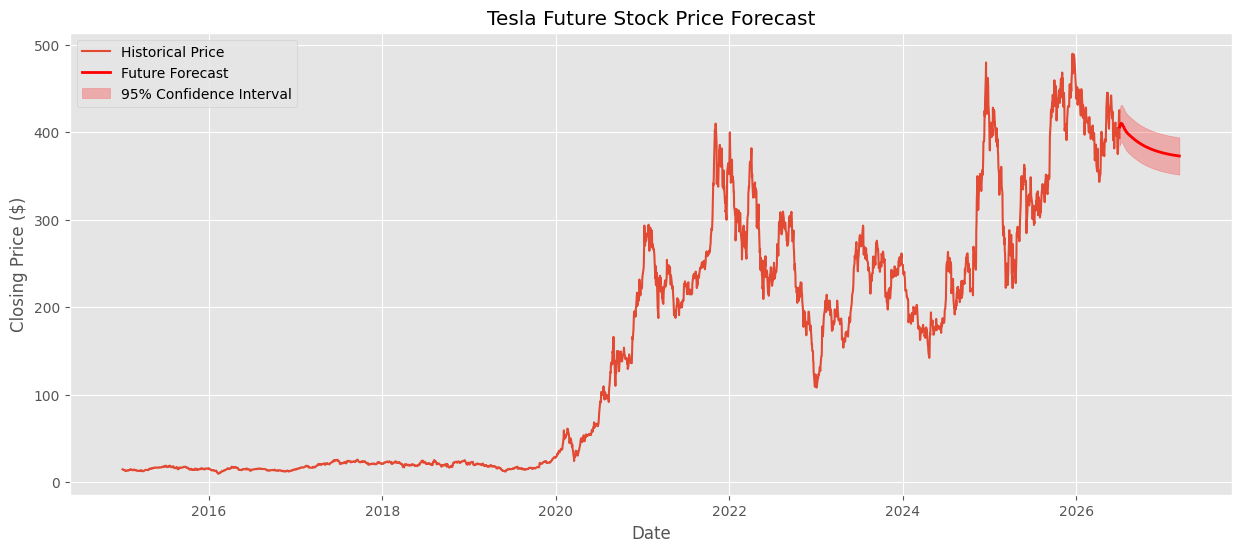

In [10]:
plt.figure(figsize=(15,6))

plt.plot(
    df.index,
    df["Close"],
    label="Historical Price"
)

plt.plot(
    future_dates,
    future_predictions,
    color="red",
    linewidth=2,
    label="Future Forecast"
)

plt.fill_between(
    future_dates,
    lower,
    upper,
    color="red",
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("Tesla Future Stock Price Forecast")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.legend()

plt.show()

In [11]:
forecast_df = pd.DataFrame({
    "Forecast": future_predictions.flatten(),
    "Lower CI": lower,
    "Upper CI": upper
}, index=future_dates)

forecast_df.head(10)

,Forecast,Lower CI,Upper CI
2026-07-03,406.001953,384.730285,427.273621
2026-07-06,408.285309,387.013641,429.556977
2026-07-07,409.532745,388.261078,430.804413
2026-07-08,410.119812,388.848144,431.391480
2026-07-09,410.271729,389.000061,431.543396
2026-07-10,410.122559,388.850891,431.394226
2026-07-13,409.756348,388.484680,431.028015
2026-07-14,409.231201,387.959533,430.502869
2026-07-15,408.590851,387.319183,429.862519
2026-07-16,407.871185,386.599518,429.142853
